<a href="https://colab.research.google.com/github/Shashank-Karanam/6thSem-ML-Lab/blob/main/1BM23CS312_Lab_7_IRIS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Build a SVM classifier to classify IRIS flower dataset using the kernels RBF and linear.

Use 80% of data for training and 20% for testing.

Display accuracy score and confusion matrix of the trained model on test data.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder

In [ ]:
df = pd.read_csv('iris.csv')
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [ ]:
X = df.drop(columns=['species'])
y = df['species']

In [ ]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

In [ ]:
linear_model = SVC(kernel='linear')
linear_model.fit(X_train, y_train)

SVC(kernel='linear')

Accuracy: 1.0


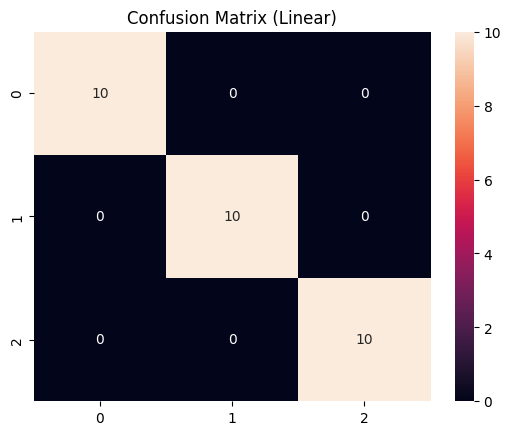

In [ ]:
y_pred = linear_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix (Linear)")
plt.show()

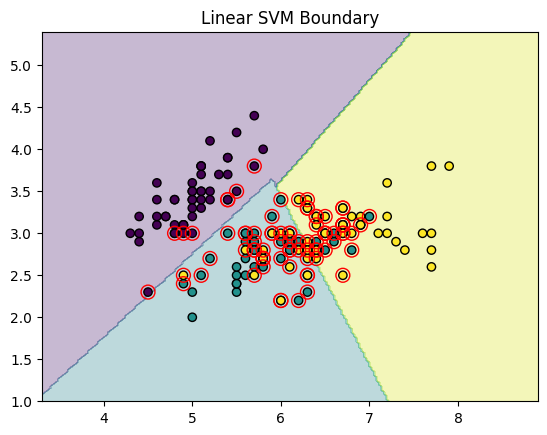

In [ ]:
# take only 2 features for visualization
X_vis = X[['sepal_length', 'sepal_width']]
y_vis = y_encoded

model = SVC(kernel='linear')
model.fit(X_vis, y_vis)

# mesh grid
x_min, x_max = X_vis.iloc[:, 0].min() - 1, X_vis.iloc[:, 0].max() + 1
y_min, y_max = X_vis.iloc[:, 1].min() - 1, X_vis.iloc[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

grid = pd.DataFrame(np.c_[xx.ravel(), yy.ravel()], columns=X_vis.columns)
Z = model.predict(grid).reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X_vis.iloc[:, 0], X_vis.iloc[:, 1], c=y_vis, edgecolors='k')

# support vectors
plt.scatter(model.support_vectors_[:,0],
            model.support_vectors_[:,1],
            s=100, facecolors='none', edgecolors='red')

plt.title("Linear SVM Boundary")
plt.show()

In [ ]:
rbf_model = SVC(kernel='rbf')
rbf_model.fit(X_train, y_train)

SVC()

Accuracy: 0.9666666666666667


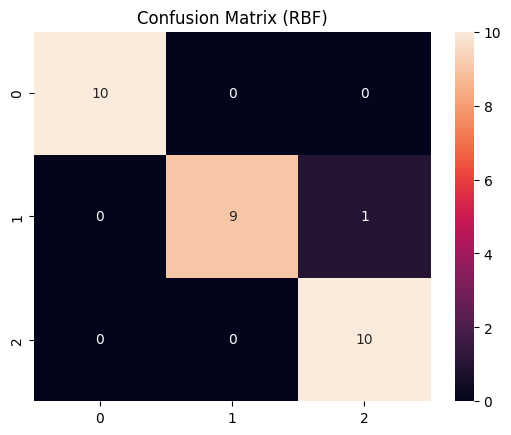

In [ ]:
y_pred_rbf = rbf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rbf))

cm = confusion_matrix(y_test, y_pred_rbf)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix (RBF)")
plt.show()

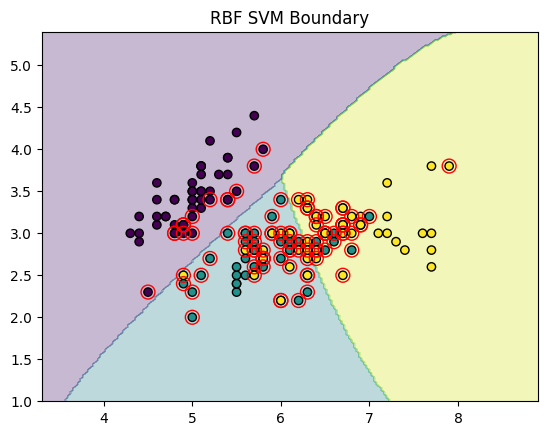

In [ ]:
model = SVC(kernel='rbf')
model.fit(X_vis, y_vis)

Z = model.predict(grid).reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X_vis.iloc[:, 0], X_vis.iloc[:, 1], c=y_vis, edgecolors='k')

# support vectors
plt.scatter(model.support_vectors_[:,0],
            model.support_vectors_[:,1],
            s=100, facecolors='none', edgecolors='red')

plt.title("RBF SVM Boundary")
plt.show()

Build a SVM classifier to classify Letter-recognition data set

Use 80% of data for training and 20% for testing.

Display accuracy score and confusion matrix of the trained model on test data. Plot the ROC curve
and display AUC score.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

In [ ]:
df = pd.read_csv('letter-recognition.csv')
df.head()

,letter,xbox,ybox,width,height,onpix,xbar,ybar,x2bar,y2bar,xybar,x2ybar,xy2bar,xedge,xedgey,yedge,yedgex
0,T,2,8,3,5,1,8,13,0,6,6,10,8,0,8,0,8
1,I,5,12,3,7,2,10,5,5,4,13,3,9,2,8,4,10
2,D,4,11,6,8,6,10,6,2,6,10,3,7,3,7,3,9
3,N,7,11,6,6,3,5,9,4,6,4,4,10,6,10,2,8
4,G,2,1,3,1,1,8,6,6,6,6,5,9,1,7,5,10


In [ ]:
X = df.drop(columns=[df.columns[0]])   # features
y = df[df.columns[0]]                 # label (letters A–Z)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
model = SVC(kernel='rbf', probability=True)
model.fit(X_train, y_train)

SVC(probability=True)

Accuracy: 0.93025


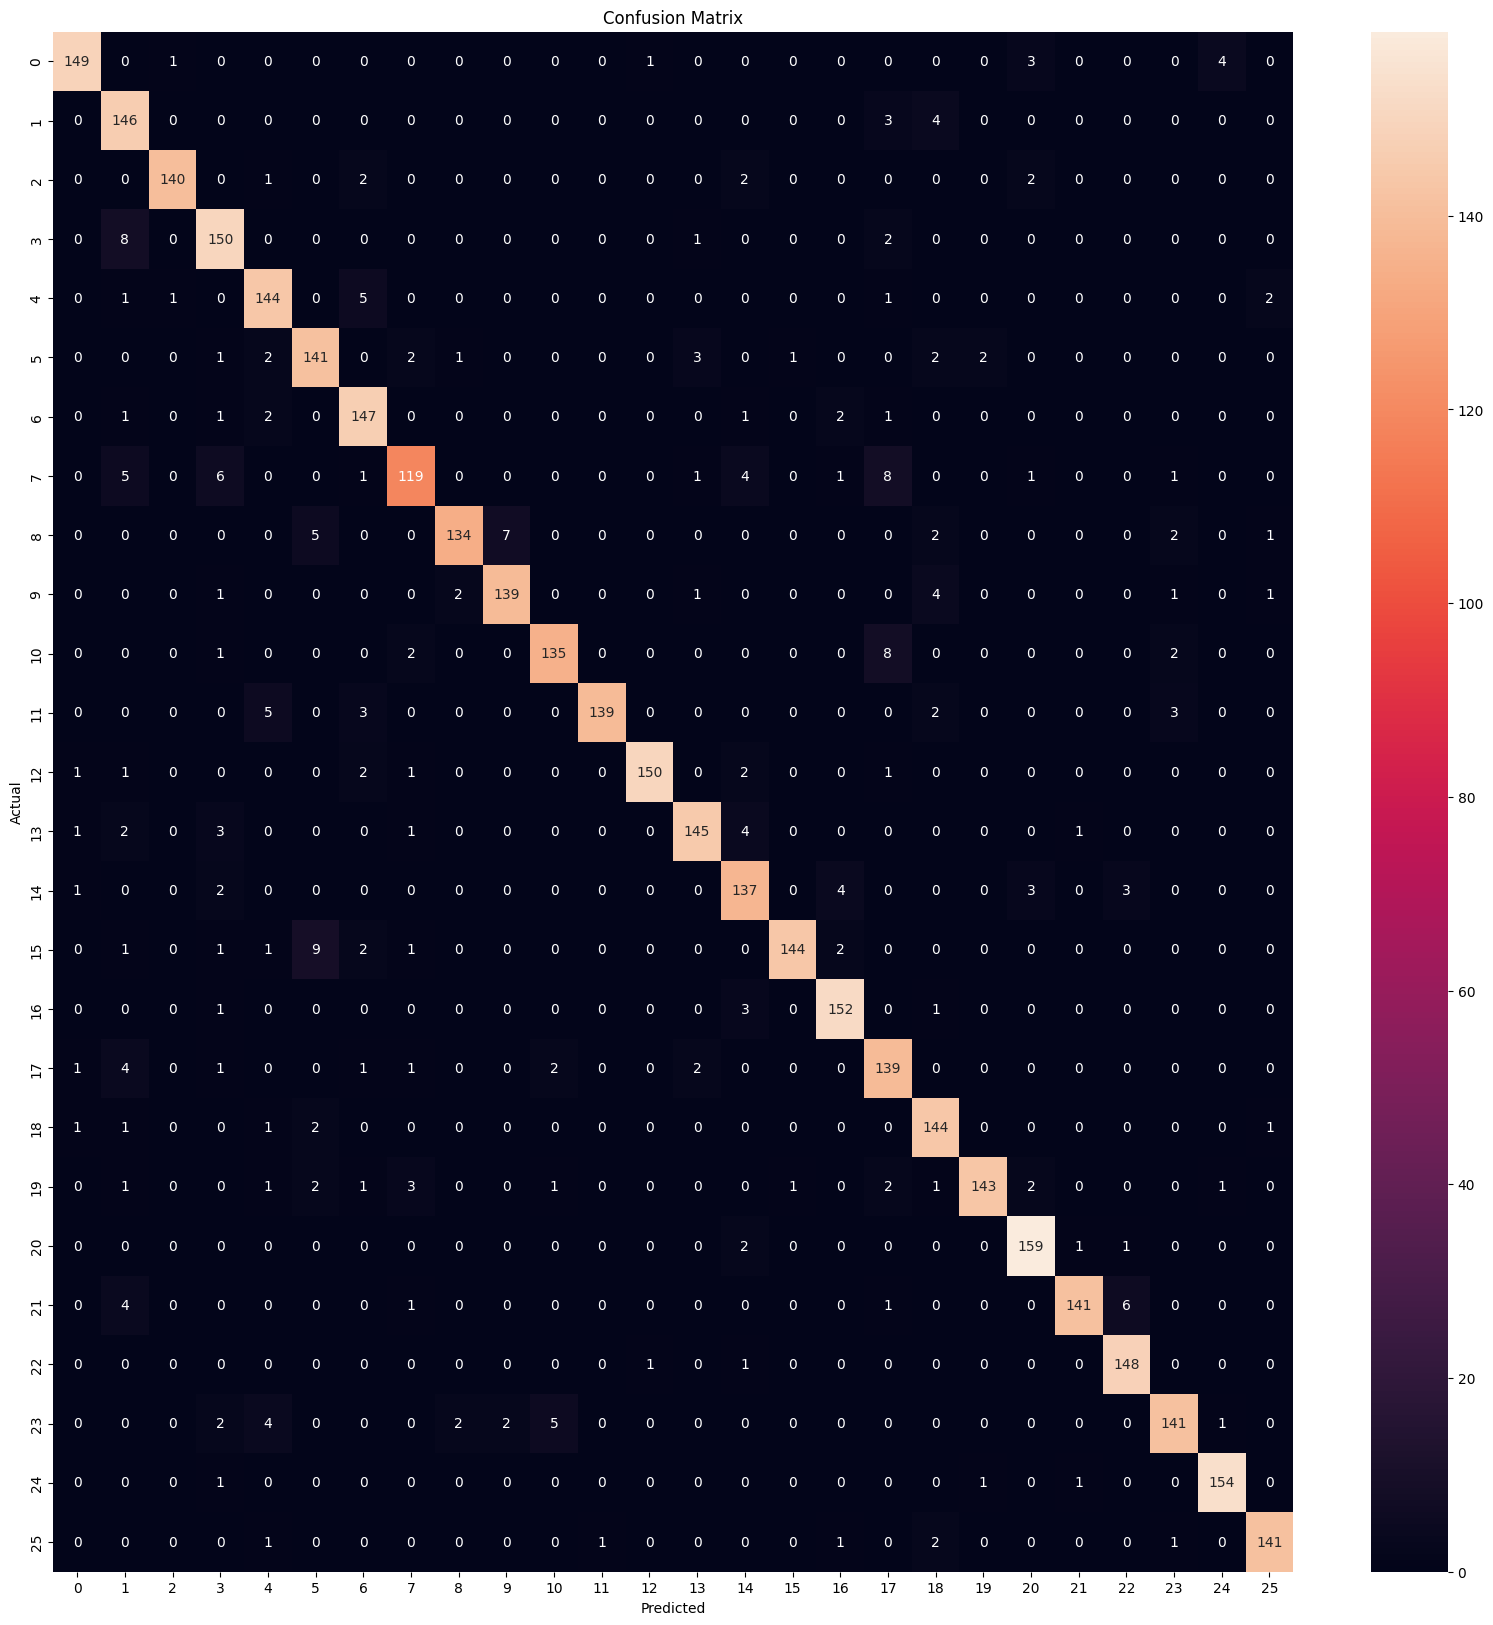

In [ ]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(20,20))
sns.heatmap(cm, annot=True, fmt='d')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

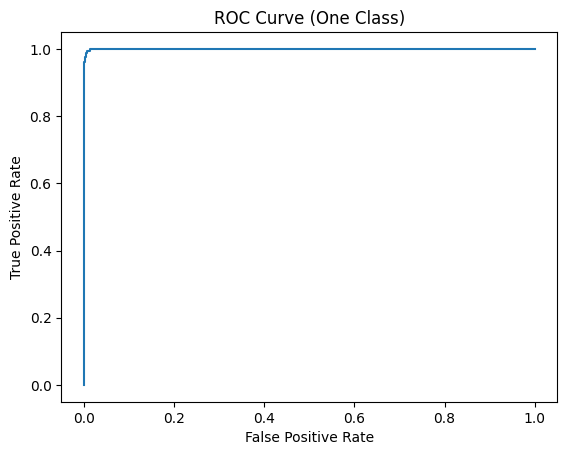

AUC Score: 0.9997479556401927


In [ ]:
# Binarize labels
classes = np.unique(y)
y_test_bin = label_binarize(y_test, classes=classes)

# Predict probabilities
y_score = model.predict_proba(X_test)

# ROC for ONE class (example: first class)
fpr, tpr, _ = roc_curve(y_test_bin[:, 0], y_score[:, 0])
roc_auc = auc(fpr, tpr)

# Plot
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (One Class)")
plt.show()

print("AUC Score:", roc_auc)